# Hyperparameter Optimisation with Optuna — VAE & TransformerVAE

We use **Optuna's NSGA-II sampler** — a multi-objective evolutionary algorithm — to jointly
optimise reconstruction quality and latent-space structure. This gives us a Pareto front rather
than a single scalar optimum, letting us see the trade-off explicitly.

**Why this matters for our project:** our choice of `latent_dim` and `beta` directly affects the
quality of latent representations and, downstream, the drift scores we feed into the SIRC
compartmental model. A principled search gives us evidence that our hyperparameters are
near-optimal — not just eyeballed.

**Reference:** Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019).
*Optuna: A Next-generation Hyperparameter Optimization Framework*. KDD.

**Studies in this notebook:**
1. **Joint latent_dim × beta sweep** (VAE) — the two params that matter most for representation quality
2. **Downstream drift sensitivity** — shows the choice affects epidemiological validity, not just reconstruction
3. **TransformerVAE architecture sweep** — justifies d_model, nhead, num_layers

**Note:** We removed the old DiffAE branch from the cleaned submission because it is not part of the final model comparison.
It has fundamentally different training dynamics — noise prediction MSE, not reconstruction
cross-entropy — so the same objective function does not apply.

In [1]:
import os
if not os.path.exists('models'):
    !git clone https://github.com/sidms24/AML.git
    os.chdir('AML')
!pip install -q optuna datasets umap-learn plotly kaleido

Cloning into 'AML'...
remote: Enumerating objects: 259, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 259 (delta 13), reused 18 (delta 10), pack-reused 228 (from 1)
Receiving objects: 100% (259/259), 12.44 MiB | 16.50 MiB/s, done.
Resolving deltas: 100% (150/150), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 6.2 MB/s eta 0:00:00


## Setup

In [2]:
import torch, numpy as np, pandas as pd
import optuna
from optuna.visualization import (
    plot_optimization_history, plot_param_importances,
    plot_slice, plot_contour
)
from tqdm import tqdm
# force plain text progress bars before importing HF libraries
import tqdm.auto, tqdm.std
tqdm.auto.tqdm = tqdm.std.tqdm
import joblib, warnings, os
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from utils.dataloader import load_data
from utils.encoders import dna_one_hot
from utils.drift import compute_drift_scores
from utils.inference import extract_latents
from utils.loss import VAE_Loss
from utils.train import VAE_train
from models.vae import VAE
from utils.sweep_config import VAE_FIXED
from utils.param_sweep import run_vae_sweep
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True

os.makedirs('results', exist_ok=True)

HIDDEN_DIM = 64


Device: cuda


In [3]:
# we use H1N1_global for the ablation — same dataset as the main training notebook
h1n1_data = load_data(subtype='H1N1_global', encoder=dna_one_hot, batch_size=512)
h1n1_train, h1n1_test = h1n1_data()

sample_x, _ = next(iter(h1n1_train))
INPUT_DIM = sample_x.shape[1]
SEQ_LENGTH = sample_x.shape[2]
print(f'H1N1 — input_dim={INPUT_DIM}, seq_length={SEQ_LENGTH}, '
      f'train batches={len(h1n1_train)}, test batches={len(h1n1_test)}')

Map (num_proc=4): 100%|██████████| 6245/6245 [00:01<00:00, 4578.09 examples/s]


H1N1 — input_dim=5, seq_length=1759, train batches=49, test batches=13


## Study 1: Joint latent_dim × beta sweep (VAE)

The two hyperparameters that most affect our downstream task are:

- **`latent_dim`** — controls the capacity of the latent space. Too small → can't capture
  variation between seasons. Too large → curse of dimensionality makes L2 drift distances meaningless.
- **`beta`** (KL weight) — controls the trade-off between reconstruction quality and latent
  space regularity. Too low → unstructured latent space. Too high → posterior collapse where
  the encoder ignores the input.

We search these **jointly** because they interact: a small latent space can tolerate higher
beta (the regularisation pressure is spread across fewer dimensions), while a large latent
space may need lower beta to avoid wasting capacity.

All other hyperparameters are **fixed** to their production values for a fair comparison.
We train for 40 epochs (vs 80 in production) since we care about relative ordering, not
absolute best performance.

In [ ]:
vae_study = run_vae_sweep(h1n1_train, h1n1_test, INPUT_DIM,
                          SEQ_LENGTH, device, hidden_dim=HIDDEN_DIM)
joblib.dump(vae_study, 'results/optuna_study_vae.pkl')
print(f'Saved study with {len(vae_study.trials)} trials.')

In [5]:
# results table — filter out diverged trials
rows = []
for t in vae_study.trials:
    if t.values[0] == float('inf'):
        continue
    rows.append({
        'trial': t.number,
        'latent_dim': t.params['latent_dim'],
        'beta': round(t.params['beta'], 3),
        'test_recon': round(t.values[0], 4),
        'silhouette': round(-t.values[1], 4),
        'test_kl': round(t.user_attrs['test_kl'], 4),
        'kl_collapsed': t.user_attrs['kl_collapsed'],
        'epochs': t.user_attrs['epochs_trained'],
    })
df_vae = pd.DataFrame(rows).sort_values('test_recon')
df_vae.to_csv('results/optuna_vae_results.csv', index=False)
df_vae

,trial,latent_dim,beta,test_recon,silhouette,test_kl,kl_collapsed,epochs
12,13,32,0.128,15.9585,0.0470,37.6186,False,40
10,11,64,0.218,16.2608,0.0593,36.9197,False,40
3,4,16,0.120,17.4819,0.0339,30.0927,False,40
0,0,16,0.184,17.5035,0.0497,26.2570,False,40
11,12,16,0.134,18.4197,0.0381,26.8961,False,40
8,9,16,0.357,19.6762,0.0563,18.2356,False,40
6,7,16,0.765,22.6285,0.0450,13.8564,False,40
13,14,128,0.634,22.6920,0.0553,15.3205,False,40
5,6,32,0.694,22.7427,0.0590,15.0182,False,40
14,15,128,0.690,24.0668,0.0532,14.1172,False,40


In [6]:
# Pareto front — these are the non-dominated trials
print(f'Pareto front: {len(vae_study.best_trials)} trials')
for t in vae_study.best_trials:
    print(f"  #{t.number}: latent_dim={t.params['latent_dim']}, "
          f"beta={t.params['beta']:.3f}, recon={t.values[0]:.4f}, "
          f"sil={-t.values[1]:.4f}")

Pareto front: 3 trials
  #11: latent_dim=64, beta=0.218, recon=16.2608, sil=0.0593
  #13: latent_dim=32, beta=0.128, recon=15.9585, sil=0.0470
  #19: latent_dim=128, beta=0.825, recon=25.2251, sil=0.0622


### Optimisation history
Shows convergence — are later trials finding better configs?

In [7]:
plot_optimization_history(vae_study, target=lambda t: t.values[0],
                          target_name='test_recon')

### Parameter importances
If `latent_dim` dominates, that validates our focus on it as the key capacity knob.
If `beta` dominates, it suggests the KL regularisation weight matters more than raw capacity.

In [8]:
plot_param_importances(vae_study, target=lambda t: t.values[0],
                       target_name='test_recon')

[W 2026-03-31 14:40:25,586] Trial 3 is omitted in visualization because its objective value is inf or nan.


### Contour plot
Shows the interaction surface between `latent_dim` and `beta`. Look for:
- Is there a clear sweet spot?
- Do high beta + low latent_dim cause posterior collapse?

In [9]:
plot_contour(vae_study, params=['latent_dim', 'beta'],
             target=lambda t: t.values[0], target_name='test_recon')

[W 2026-03-31 14:40:25,871] Trial 3 is omitted in visualization because its objective value is inf or nan.


### Slice plot
Marginal effect of each parameter.

In [10]:
plot_slice(vae_study, params=['latent_dim', 'beta'],
           target=lambda t: t.values[0], target_name='test_recon')

[W 2026-03-31 14:40:25,941] Trial 3 is omitted in visualization because its objective value is inf or nan.


## Study 2: Downstream drift sensitivity

This is what makes the ablation more than a generic hyperparameter sweep — it shows
the choice matters for the epidemiological application. We take the best and worst
configs from Study 1, retrain them, compute drift scores, and correlate with CDC
hospitalisation rates.

In [11]:
# pick the best and worst configs by reconstruction loss from the Pareto front
valid_trials = [t for t in vae_study.trials if t.values[0] != float('inf')]
sorted_by_recon = sorted(valid_trials, key=lambda t: t.values[0])
best_trial = sorted_by_recon[0]
worst_trial = sorted_by_recon[-1]

configs = {
    'best':  {'latent_dim': best_trial.params['latent_dim'],
              'beta': best_trial.params['beta']},
    'worst': {'latent_dim': worst_trial.params['latent_dim'],
              'beta': worst_trial.params['beta']},
}
print('Best config: ', configs['best'])
print('Worst config:', configs['worst'])

Best config:  {'latent_dim': 32, 'beta': 0.12822825454807552}
Worst config: {'latent_dim': 16, 'beta': 4.44475416669081}


In [12]:
# retrain best and worst configs to get models we can extract latents from
drift_models = {}
for label, cfg in configs.items():
    print(f'\nTraining {label}: latent_dim={cfg["latent_dim"]}, beta={cfg["beta"]:.3f}')
    torch.manual_seed(42)
    model = VAE(INPUT_DIM, HIDDEN_DIM, cfg['latent_dim'], SEQ_LENGTH).to(device)
    criterion = VAE_Loss(beta=cfg['beta'])
    optimiser = torch.optim.Adam(model.parameters(), lr=VAE_FIXED['lr'])
    model, history = VAE_train(
        model, h1n1_train, h1n1_test,
        criterion, optimiser, device,
        epochs=80, patience=5, anneal_epochs=10, save_every=50,
    )
    drift_models[label] = model
    print(f'  Final test recon: {history["test_recon_loss"][-1]:.4f}')


Training best: latent_dim=32, beta=0.128
Auto-Detected Shapes: Input 1759 -> Compressed to 220
  Checkpoint saved at epoch 50 -> checkpoint.pt

Early stopping triggered at Epoch 63.
Training:  78%|███████▊  | 62/80 [02:16<00:39,  2.21s/epoch, avg loss=192.6456]
  Final test recon: 163.4997

Training worst: latent_dim=16, beta=4.445
Auto-Detected Shapes: Input 1759 -> Compressed to 220
  Checkpoint saved at epoch 50 -> checkpoint.pt
Training: 100%|██████████| 80/80 [02:52<00:00,  2.16s/epoch, avg loss=46.9230]
  Final test recon: 31.7608


In [13]:

from datasets import load_dataset
from utils.encoders import dna_one_hot
from utils.dataloader import _collate_mixed
from torch.utils.data import DataLoader
raw = load_dataset('sidms/AML', 'H1N1_drift')


encoder = dna_one_hot()
ds = raw['train'].map(encoder, batched=True, num_proc=4, remove_columns=['sequence'])
ds.set_format(type='torch', columns=['input_ids', 'year'], output_all_columns=True)

h1n1_drift = DataLoader(ds, batch_size=512, shuffle=False,
                         collate_fn=_collate_mixed, num_workers=4, pin_memory=True)

Map (num_proc=4): 100%|██████████| 25760/25760 [00:04<00:00, 5300.25 examples/s]


In [14]:
# extract latents and compute drift scores for both configs
drift_results = {}
for label, model in drift_models.items():
    result = extract_latents(model, h1n1_drift, device=device)
    latents, years = result[0], result[1]
    months = result[3] if len(result) > 3 else None
    seasons = result[4] if len(result) > 4 else None
    drift_df = compute_drift_scores(latents, years, months=months,
                                    seasons=seasons, max_per_season = 30)
    drift_results[label] = drift_df

drift_results['best']

,season,drift_raw,n_sequences,centroid,drift_norm
0,2009-10,1.083917,644,"[3.1311197, -3.771875, 0.34069416, -2.0620768,...",0.500000
1,2010-11,1.100738,134,"[2.8491862, -4.1315103, 0.5129842, -1.8261068,...",1.000000
2,2011-12,2.315891,42,"[3.1920574, -4.4700522, 0.89857584, -1.1731282...",1.000000
3,2012-13,1.909567,34,"[3.071159, -4.4628906, 0.59515697, -1.5882568,...",0.670184
4,2013-14,1.867241,112,"[3.2266276, -4.1822915, 0.6813965, -2.3827798,...",0.635828
5,2014-15,2.885158,140,"[2.838086, -3.1698892, -0.2902018, -1.9275717,...",1.000000
6,2015-16,2.806221,1524,"[2.9869792, -3.395703, 0.25089213, -1.9005859,...",0.956176
7,2016-17,1.083800,548,"[3.4400392, -3.2746093, 0.4979309, -1.8537434,...",0.000000
8,2017-18,2.101206,1173,"[2.9342449, -3.3764322, 0.64012045, -1.7024089...",0.564800
9,2018-19,0.916435,2509,"[3.1040366, -3.264323, 0.5303955, -1.59611, 0....",0.000000


In [15]:
# load CDC hospitalisation data
HF_REPO = 'sidms/AML'
HF_BASE = f'https://huggingface.co/datasets/{HF_REPO}/resolve/main'
season_summary = pd.read_csv(f'{HF_BASE}/cdc_data/season_summary.csv')
hosp = season_summary[['season', 'hosp_rate_overall']].dropna(subset=['hosp_rate_overall'])
print(f'Hospitalisation data: {len(hosp)} seasons')
hosp.head()

Hospitalisation data: 17 seasons


,season,hosp_rate_overall
12,2009-10,29.3
13,2010-11,21.5
14,2011-12,8.7
15,2012-13,44.0
16,2013-14,35.1


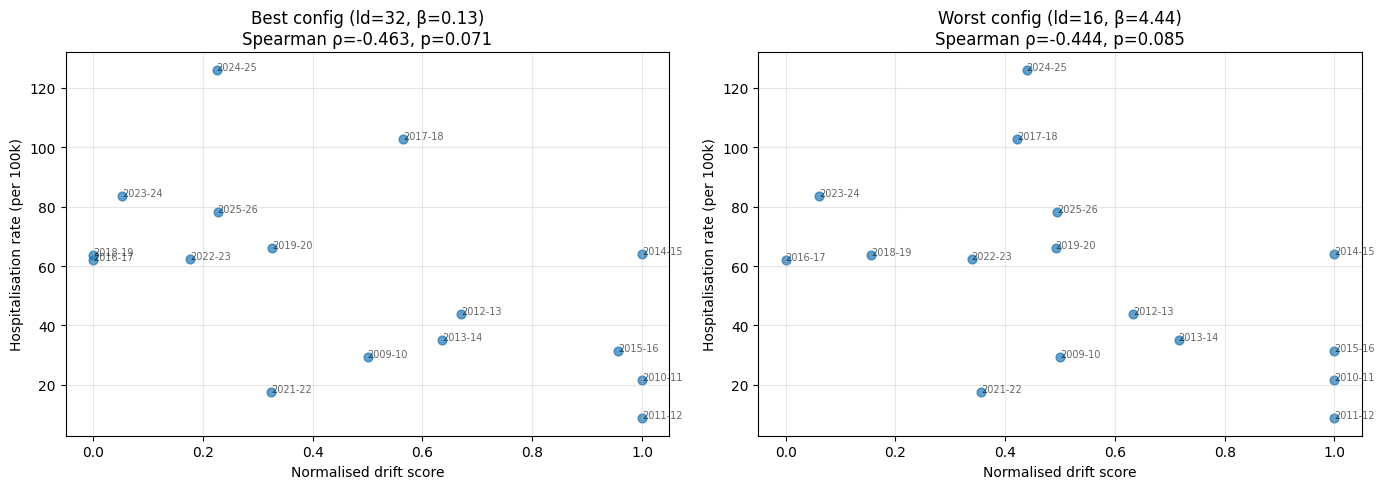

In [16]:
# compute Spearman correlation between drift and hospitalisation for each config
from scipy.stats import rankdata

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, drift_df) in zip(axes, drift_results.items()):
    merged = drift_df.merge(hosp, on='season', how='inner')
    # exclude 2020-21 (COVID disruption)
    merged = merged[merged['season'] != '2020-21']

    rho, pval = spearmanr(merged['drift_norm'], merged['hosp_rate_overall'])

    ax.scatter(merged['drift_norm'], merged['hosp_rate_overall'], s=40, alpha=0.7)
    for _, row in merged.iterrows():
        ax.annotate(row['season'], (row['drift_norm'], row['hosp_rate_overall']),
                    fontsize=7, alpha=0.6)
    cfg = configs[label]
    ax.set_title(f"{label.title()} config (ld={cfg['latent_dim']}, β={cfg['beta']:.2f})\n"
                 f"Spearman ρ={rho:.3f}, p={pval:.3f}")
    ax.set_xlabel('Normalised drift score')
    ax.set_ylabel('Hospitalisation rate (per 100k)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/drift_sensitivity_best_vs_worst.png', dpi=150, bbox_inches='tight')
plt.show()

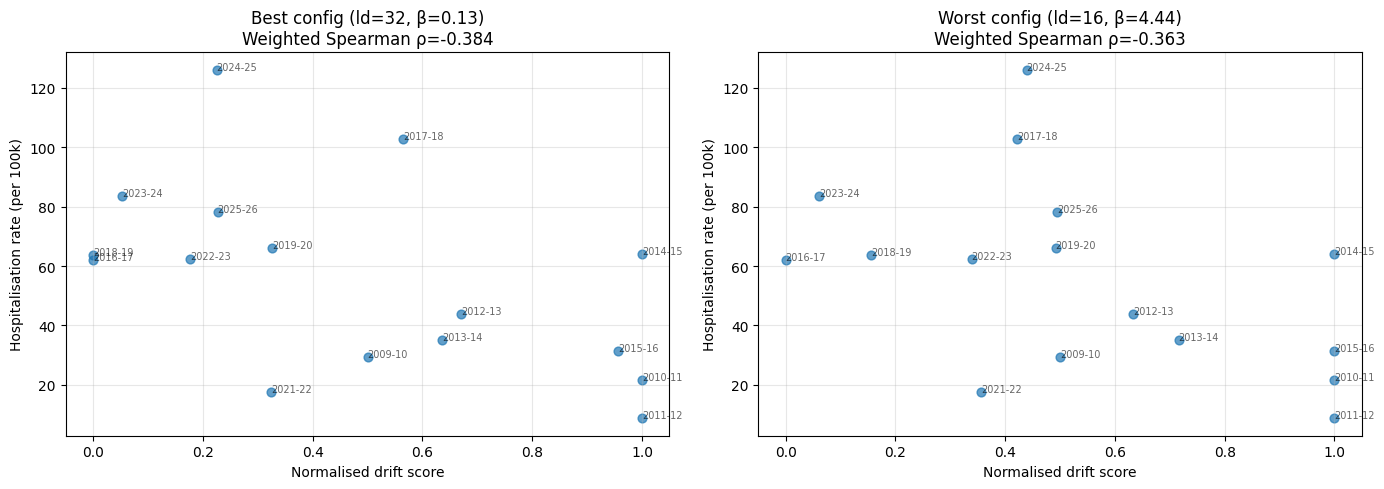

In [17]:
# weighted Spearman correlation between drift and hospitalisation for each config

def weighted_corr(x, y, w):
    mx = np.average(x, weights=w)
    my = np.average(y, weights=w)
    cov = np.average((x - mx) * (y - my), weights=w)
    sx = np.sqrt(np.average((x - mx)**2, weights=w))
    sy = np.sqrt(np.average((y - my)**2, weights=w))
    return cov / (sx * sy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, drift_df) in zip(axes, drift_results.items()):
    merged = drift_df.merge(hosp, on='season', how='inner')
    merged = merged[merged['season'] != '2020-21']

    ranks_drift = rankdata(merged['drift_norm'])
    ranks_hosp = rankdata(merged['hosp_rate_overall'])
    weights = merged['n_sequences'].values

    rho_w = weighted_corr(ranks_drift, ranks_hosp, weights)

    ax.scatter(merged['drift_norm'], merged['hosp_rate_overall'], s=40, alpha=0.7)
    for _, row in merged.iterrows():
        ax.annotate(row['season'], (row['drift_norm'], row['hosp_rate_overall']),
                    fontsize=7, alpha=0.6)
    cfg = configs[label]
    ax.set_title(f"{label.title()} config (ld={cfg['latent_dim']}, β={cfg['beta']:.2f})\n"
                 f"Weighted Spearman ρ={rho_w:.3f}")
    ax.set_xlabel('Normalised drift score')
    ax.set_ylabel('Hospitalisation rate (per 100k)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/drift_sensitivity_best_vs_worst.png', dpi=150, bbox_inches='tight')
plt.show()